In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from data import *
from matplotlib.colors import ListedColormap
import subprocess
from rnaplot_wsl import rnaplot_svg
from rnaplot_matplotlib import plot_rna_matplotlib
import matplotlib
import string

In [2]:
DATA_PATH = "synthetic+real_dataset_filtered_numpeaks.parquet"
EMBEDDING_PATH = "../modular_setup_improved/all_fm-rna_embeddings_filtered.pt"

BIN_EDGES_PATH = "bin_edges.npy"
SEED = 42
N_BINS = 50
LOCAL_MINIMA_K = 10  # how many rank-ordered local minima to featurize for all_local_MLP
DEVICE = "cpu"  # change to "cuda" if available

In [57]:
embeddings_dict = torch.load(EMBEDDING_PATH)

In [58]:
handpicked_cols = ["gc_content", "mfe", "n_local_minima"]

data = prepare_data(
    DATA_PATH, n_bins=N_BINS, random_state=SEED, handpicked_cols=handpicked_cols,
    bin_edges_path=BIN_EDGES_PATH, data_mask=None,
    local_minima_k=LOCAL_MINIMA_K,
)

In [59]:
data.train.static_features.shape

(7459, 33)

In [7]:
data.train.static_features[0,:]

array([-0.9046179 , -0.05064828,  0.36065495,  0.38703063,  1.311612  ,
        0.5503368 , -0.15105651,  0.81237394,  0.40409157, -0.14994423,
        3.099931  ,  0.92454624, -0.26401842,  2.7084234 ,  0.88931525,
       -0.29671484,  1.3019705 ,  0.724348  , -0.1234295 ,  0.9931097 ,
        0.36973375,  0.05466486,  2.8996422 ,  0.9294365 ,  0.06427446,
        2.870975  ,  0.87740463,  0.09402581,  2.4532611 ,  0.8754226 ,
        0.24935468, -0.1773027 ,  0.43668923], dtype=float32)

In [14]:
data.train.sequences[0].shape

(65, 4)

In [3]:
df = pd.read_parquet(DATA_PATH)

In [4]:
for key in df.keys():
    print(key)

index
filepath
sequence
length
mfe_from_file
dot_bracket_from_file
fpts
gc_content
freq_A
freq_U
freq_G
freq_C
freq_AA
freq_AU
freq_AG
freq_AC
freq_UA
freq_UU
freq_UG
freq_UC
freq_GA
freq_GU
freq_GG
freq_GC
freq_CA
freq_CU
freq_CG
freq_CC
mfe
mfe_structure
n_local_minima
min_1_structure
min_1_energy
min_1_bp_dist
min_2_structure
min_2_energy
min_2_bp_dist
min_3_structure
min_3_energy
min_3_bp_dist
min_4_structure
min_4_energy
min_4_bp_dist
min_5_structure
min_5_energy
min_5_bp_dist
min_6_structure
min_6_energy
min_6_bp_dist
min_7_structure
min_7_energy
min_7_bp_dist
min_8_structure
min_8_energy
min_8_bp_dist
min_9_structure
min_9_energy
min_9_bp_dist
min_10_structure
min_10_energy
min_10_bp_dist
min_11_structure
min_11_energy
min_11_bp_dist
min_12_structure
min_12_energy
min_12_bp_dist
min_13_structure
min_13_energy
min_13_bp_dist
min_14_structure
min_14_energy
min_14_bp_dist
min_15_structure
min_15_energy
min_15_bp_dist
min_16_structure
min_16_energy
min_16_bp_dist
min_17_structure
mi

In [56]:
df['sequence'][60]

'AAGGGUACUAACACCACCAUCUAUUGGGCCCCGAGUAAUGGCCCAUAGAGUUAAUAGGGUCU'

In [57]:
df['dot_bracket_from_file'][60]

'...(((......)))....(((((.(((((.........)))))))))).............'

In [26]:
def get_bp_value(nuc1, nuc2):
    if (nuc1 == 'A' and nuc2 == 'U') or (nuc1 == 'U' and nuc2 == 'A'):
        return 1
    if (nuc1 == 'G' and nuc2 == 'C') or (nuc1 == 'C' and nuc2 == 'G'):
        return 2
    if (nuc1 == 'G' and nuc2 == 'U') or (nuc1 == 'U' and nuc2 == 'G'):
        return 3
    else:
        raise ValueError(f"Nucleotides {nuc1} and {nuc2} do not form a valid base pair")

def dotbrack_seq_to_colored_matrix(dot_bracket_string, seq_string):    
    n = len(dot_bracket_string)
    if len(seq_string) != n:
        raise ValueError("dot_bracket_string and seq_string must be the same length")
    # 1. Initialize an N x N matrix with zeros
    matrix = [[0 for _ in range(n)] for _ in range(n)]
    stack = []
    nuc_stack = []
    
    # 2. Loop through the string
    for i, char in enumerate(dot_bracket_string):
        nuc = seq_string[i] # nucleotide
        if char == '(':
            stack.append(i) # Save the index of the open bracket
            nuc_stack.append(nuc) # save the first nucleotide of the base pair
        elif char == ')':
            if stack:
                j = stack.pop() # Retrieve the matching open bracket index
                nuc1 = nuc_stack.pop() # retrieve the first nucleotide of the base pair
                
                bp_value = get_bp_value(nuc1, nuc)

                # 3. Mark the base pair (convert from 0-based to 1-based index if desired)
                matrix[i][j] = bp_value
                matrix[j][i] = bp_value
                
    return matrix

...(((......)))....(((((.(((((.........)))))))))).............
AAGGGUACUAACACCACCAUCUAUUGGGCCCCGAGUAAUGGCCCAUAGAGUUAAUAGGGUCU
62


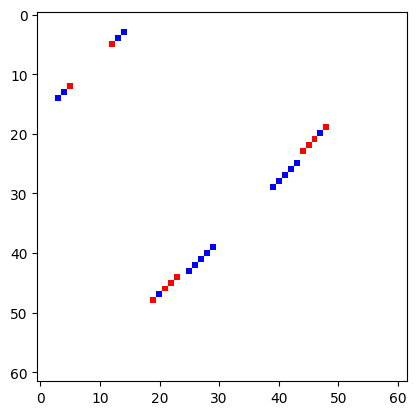

In [27]:
dotbracket = df.loc[60, 'mfe_structure']
seq = df.loc[60, 'sequence']
print(dotbracket)
print(seq)
print(len(dotbracket))
bpgrid = dotbrack_seq_to_colored_matrix(dotbracket, seq)

# no bp, AU, GC, GU
custom_colors = ['white', 'red', 'blue', 'yellow']
cmap = ListedColormap(custom_colors)
plt.imshow(bpgrid, cmap=cmap, vmin=0, vmax=3)

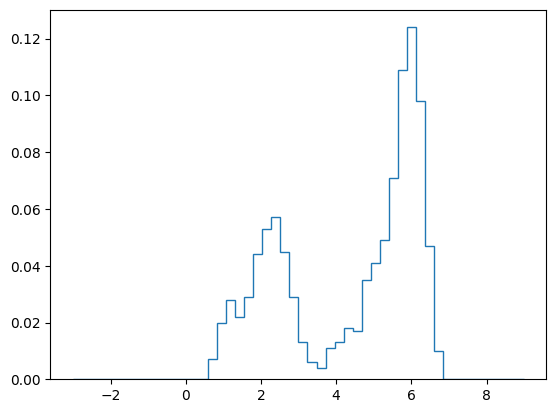

In [28]:
plt.stairs(df.loc[60,'dist'], np.load(BIN_EDGES_PATH)/np.log(10))

In [29]:
np.sum(df.loc[60,'dist'])

np.float64(1.0)

In [30]:
df.loc[60, 'num_peaks']

np.int64(2)

In [31]:
KINFOLD = "/usr/bin/Kinfold"

def run_kinfold(sequence, num=10, time=100, temp=37, seed=None, extra_args=None):

    args = ["wsl", "--", KINFOLD, "--num", str(num), "--time", str(time), "--Temp", str(temp)]
    if seed is not None:
        args += ["--seed", f"{seed}={seed}={seed}"]
    if extra_args:
        args += extra_args

    stdin_input = f"{sequence}"

    result = subprocess.run(
        args,
        input=stdin_input,
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        raise RuntimeError(f"Kinfold failed:\n{result.stderr}")

    fpt_times = []

    timed_out = 0

    for line in result.stdout.splitlines():
        if "X1" in line:
            parts = line.split()
            fpt_times.append(float(parts[2]))  # time is the 3rd column

    timed_out = num - len(fpt_times)

    return {
        "fpt_times": fpt_times,
        "reached_mfe": len(fpt_times),
        "timed_out": timed_out
    }

In [32]:
seq = "GAAACCAUGCUAGCUAGACU"
result = run_kinfold(seq, num=5, time=10000000000, seed=229)
print(f"FPT times: {result['fpt_times']}")
print(f"Reached MFE: {result['reached_mfe']}/5")
print(f"Timed out:   {result['timed_out']}/5")

FPT times: [2.387, 0.823, 1.056, 1.837, 0.721]
Reached MFE: 5/5
Timed out:   0/5


In [ ]:
# seq = "GGGAAACCC"
# struct = "(((...)))"
# path = rnaplot_svg(seq, struct, "structure.svg")
# print(f"Saved SVG to {path}")

Saved SVG to structure.svg


In [ ]:
seq = df.loc[60, 'sequence']
struct = df.loc[60, 'mfe_structure']
path = rnaplot_svg(seq, struct, "structure.svg")
print(f"Saved SVG to {path}")

Saved SVG to structure.svg


In [45]:
seq = df.loc[10030, 'sequence']
struct = df.loc[10030, 'mfe_structure']
path = rnaplot_svg(seq, struct, "structure2.svg")
print(f"Saved SVG to {path}")

Saved SVG to structure2.svg


In [ ]:
df['sequence']

0        UCAUACAGACUUAGAUAAGAAGCCGGCACUUUUAGUCCGUCUGAAU...
1        CGCUACGGUUAUCAGACUUGAUUGUAGAGGAACAUUAAGCGGAGGA...
2        GUCUGUUUAUGGAAGGUUAUUCCGUCCCGAUAGGAUUACAACAAAU...
3        CUGGUAAGCACUGUGUGAUGGUCCCUUUGGAUCCCACGCAAUCUUC...
4        UUAUAACCAAGGCGACACAACAAGCUCACCGAGGUUCGGGUAGUGU...
                               ...                        
10960    GGCUGGUCCGAGUGUAUUGGUGUUUAGAACUAAUUCAUCACAACCA...
10961    GCAGUAAAUGGCUAAGACUUCACCAGUCAAAGCGAACUACUAUACU...
10962    GGCUGGUCCGAGUGCAGUGGUUUAUGACUAAUUAAUCACAACCAGU...
10963    AAUUGGUCUAAGUAUAGUGGUGUUUAUAACUAAUUGAUCACAAGUG...
10964    GUGCUCACUUCGGCAGCAGAUAUACUGAAUUUGGAUCAAUAUAGAG...
Name: sequence, Length: 10325, dtype: object

In [11]:
# seq = df.loc[60, 'sequence']
# struct = df.loc[60, 'mfe_structure']
# plot_rna_matplotlib(seq, struct, output_path='structure.png')

In [9]:
subprocess.run([
    "inkscape", "--export-type=png",
    "--export-dpi=150",
    "--export-filename=structure.png",
    "structure.svg",
])

CompletedProcess(args=['inkscape', '--export-type=png', '--export-dpi=150', '--export-filename=structure.png', 'structure.svg'], returncode=0)

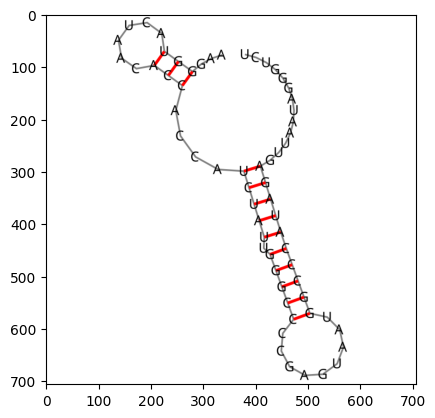

In [ ]:
plt.imshow(plt.imread('structure.png'))

In [18]:
df.loc[60, 'sequence']

'AAGGGUACUAACACCACCAUCUAUUGGGCCCCGAGUAAUGGCCCAUAGAGUUAAUAGGGUCU'

In [19]:
df.loc[60, 'mfe_structure']

'...(((......)))....(((((.(((((.........)))))))))).............'

In [21]:
for key in df.keys():
    print(key)

index
filepath
sequence
length
mfe_from_file
dot_bracket_from_file
fpts
gc_content
freq_A
freq_U
freq_G
freq_C
freq_AA
freq_AU
freq_AG
freq_AC
freq_UA
freq_UU
freq_UG
freq_UC
freq_GA
freq_GU
freq_GG
freq_GC
freq_CA
freq_CU
freq_CG
freq_CC
mfe
mfe_structure
n_local_minima
min_1_structure
min_1_energy
min_1_bp_dist
min_2_structure
min_2_energy
min_2_bp_dist
min_3_structure
min_3_energy
min_3_bp_dist
min_4_structure
min_4_energy
min_4_bp_dist
min_5_structure
min_5_energy
min_5_bp_dist
min_6_structure
min_6_energy
min_6_bp_dist
min_7_structure
min_7_energy
min_7_bp_dist
min_8_structure
min_8_energy
min_8_bp_dist
min_9_structure
min_9_energy
min_9_bp_dist
min_10_structure
min_10_energy
min_10_bp_dist
min_11_structure
min_11_energy
min_11_bp_dist
min_12_structure
min_12_energy
min_12_bp_dist
min_13_structure
min_13_energy
min_13_bp_dist
min_14_structure
min_14_energy
min_14_bp_dist
min_15_structure
min_15_energy
min_15_bp_dist
min_16_structure
min_16_energy
min_16_bp_dist
min_17_structure
mi

In [23]:
struct = '.'*5
print(struct)

.....


In [24]:
seq = df.loc[60, 'sequence']
struct = '.'*len(seq)
path = rnaplot_svg(seq, struct, "structure_unfolded.svg")
print(f"Saved SVG to {path}")

Saved SVG to structure_unfolded.svg


In [25]:
subprocess.run([
    "inkscape", "--export-type=png",
    "--export-dpi=150",
    "--export-filename=structure_unfolded.png",
    "structure_unfolded.svg",
])

CompletedProcess(args=['inkscape', '--export-type=png', '--export-dpi=150', '--export-filename=structure_unfolded.png', 'structure_unfolded.svg'], returncode=0)

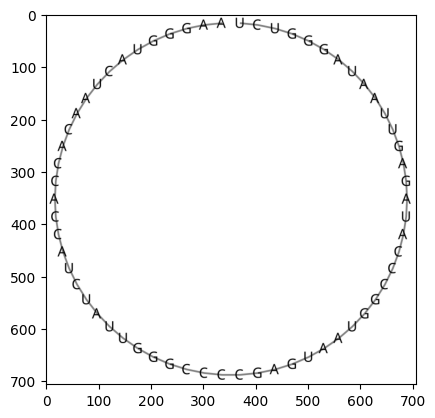

In [27]:
plt.imshow(plt.imread('structure_unfolded.png'))

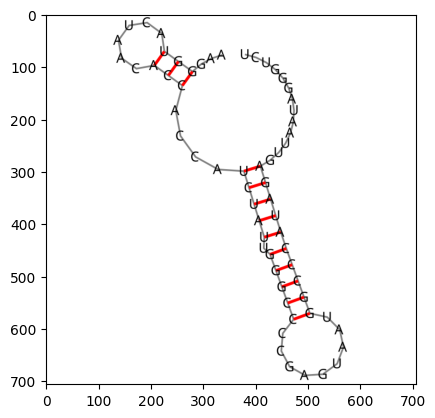

In [28]:
plt.imshow(plt.imread('structure.png'))

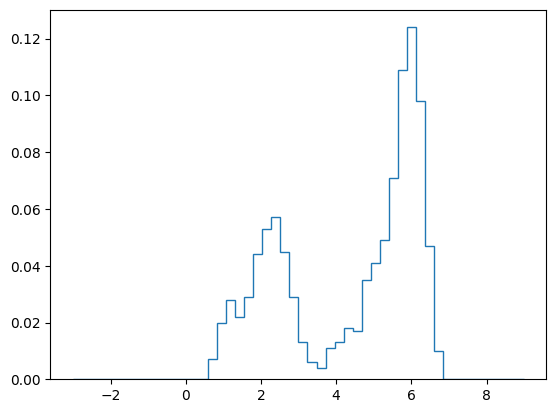

In [30]:
plt.stairs(df.loc[60,'dist'], np.load(BIN_EDGES_PATH)/np.log(10))

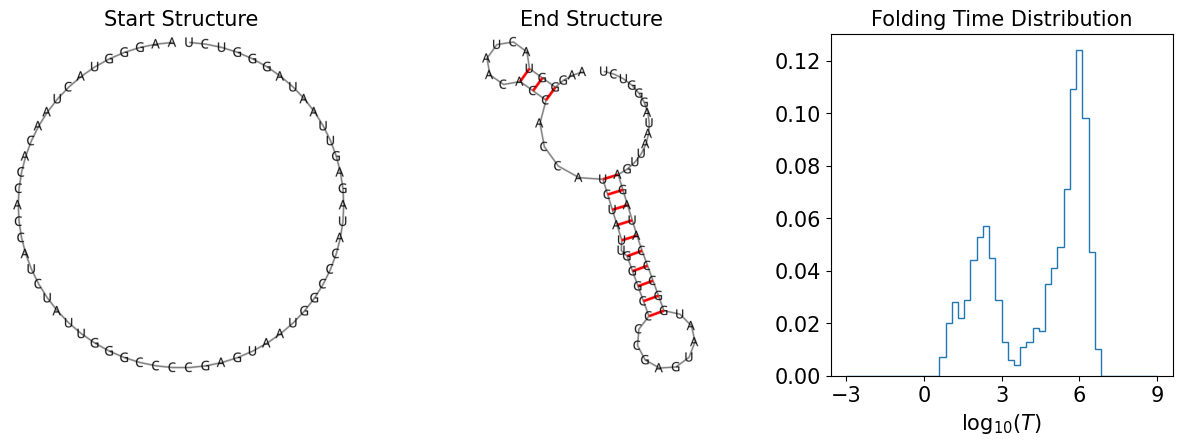

In [90]:
seq = df.loc[60, 'sequence']
struct = df.loc[60, 'mfe_structure']

fig, axs = plt.subplots(1, 3, figsize=(15,15))

matplotlib.style.use('default')

axs[0].set_title('Start Structure', size=15)
axs[0].set_axis_off()
axs[0].imshow(plt.imread('structure_unfolded.png'))

axs[1].set_title('End Structure', size=15)
axs[1].set_axis_off()
axs[1].imshow(plt.imread('structure.png'))

axs[2].set_title('Folding Time Distribution', size=15)
axs[2].set_box_aspect(1.0)
axs[2].set_xlabel(r'$\text{log}_{10}(T)$', size=15)
axs[2].set_xticks([-3,0,3,6,9])
axs[2].tick_params(axis='x', labelsize=15)
axs[2].tick_params(axis='y', labelsize=15)
axs[2].stairs(df.loc[60,'dist'], np.load(BIN_EDGES_PATH)/np.log(10))

In [91]:
index = 60

seq = df.loc[index, 'sequence']
struct = df.loc[index, 'mfe_structure']
path = rnaplot_svg(seq, struct, str(index)+"_structure.svg")
print(f"Saved SVG to {path}")

subprocess.run([
    "inkscape", "--export-type=png",
    "--export-dpi=150",
    "--export-filename="+str(index)+"_structure.png",
    str(index)+"_structure.svg",
])

seq = df.loc[index, 'sequence']
struct = '.'*len(seq)
path = rnaplot_svg(seq, struct, str(index)+"_structure_unfolded.svg")
print(f"Saved SVG to {path}")

subprocess.run([
    "inkscape", "--export-type=png",
    "--export-dpi=150",
    "--export-filename="+str(index)+"_structure_unfolded.png",
    str(index)+"_structure_unfolded.svg",
])

Saved SVG to 60_structure.svg
Saved SVG to 60_structure_unfolded.svg


CompletedProcess(args=['inkscape', '--export-type=png', '--export-dpi=150', '--export-filename=60_structure_unfolded.png', '60_structure_unfolded.svg'], returncode=0)

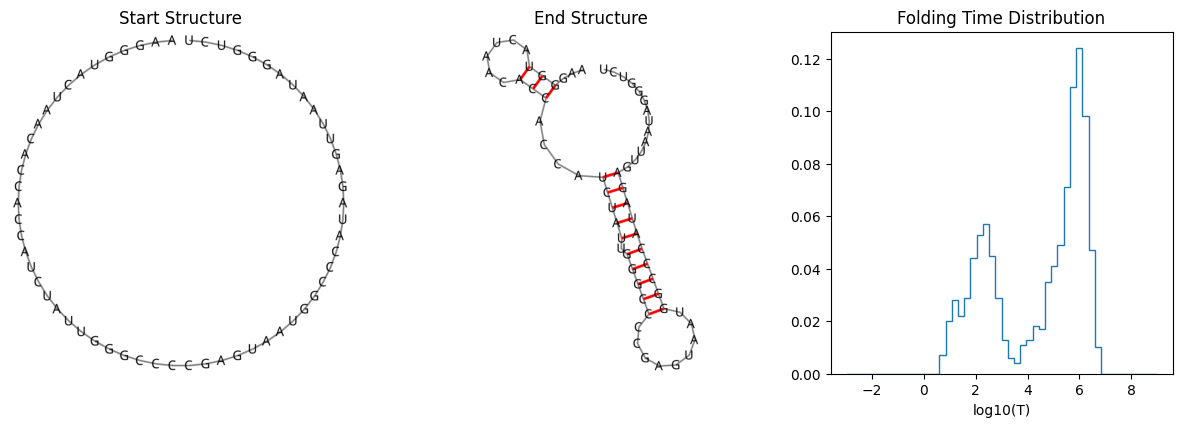

In [100]:
index = 60

seq = df.loc[index, 'sequence']
struct = df.loc[index, 'mfe_structure']

fig, axs = plt.subplots(1, 3, figsize=(15,15))

axs[0].set_title('Start Structure')
axs[0].set_axis_off()
axs[0].imshow(plt.imread(str(index)+'_structure_unfolded.png'))

axs[1].set_title('End Structure')
axs[1].set_axis_off()
axs[1].imshow(plt.imread(str(index)+'_structure.png'))

axs[2].set_title('Folding Time Distribution')
axs[2].set_box_aspect(1.0)
axs[2].set_xlabel('log10(T)')
axs[2].stairs(df.loc[index,'dist'], np.load(BIN_EDGES_PATH)/np.log(10))

In [93]:
index = 8000

seq = df.loc[index, 'sequence']
struct = df.loc[index, 'mfe_structure']
path = rnaplot_svg(seq, struct, str(index)+"_structure.svg")
print(f"Saved SVG to {path}")

subprocess.run([
    "inkscape", "--export-type=png",
    "--export-dpi=150",
    "--export-filename="+str(index)+"_structure.png",
    str(index)+"_structure.svg",
])

seq = df.loc[index, 'sequence']
struct = '.'*len(seq)
path = rnaplot_svg(seq, struct, str(index)+"_structure_unfolded.svg")
print(f"Saved SVG to {path}")

subprocess.run([
    "inkscape", "--export-type=png",
    "--export-dpi=150",
    "--export-filename="+str(index)+"_structure_unfolded.png",
    str(index)+"_structure_unfolded.svg",
])

Saved SVG to 8000_structure.svg
Saved SVG to 8000_structure_unfolded.svg


CompletedProcess(args=['inkscape', '--export-type=png', '--export-dpi=150', '--export-filename=8000_structure_unfolded.png', '8000_structure_unfolded.svg'], returncode=0)

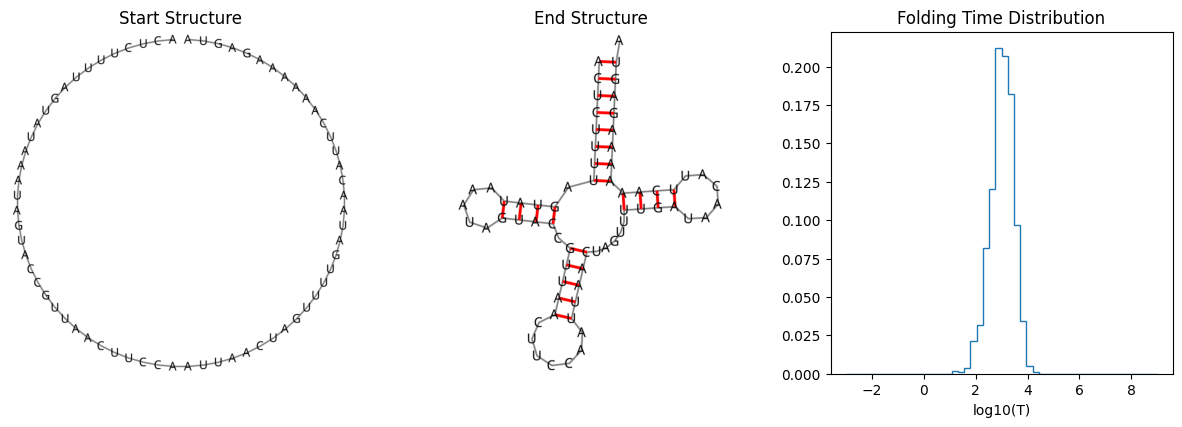

In [99]:
index = 8000

seq = df.loc[index, 'sequence']
struct = df.loc[index, 'mfe_structure']

fig, axs = plt.subplots(1, 3, figsize=(15,15))

axs[0].set_title('Start Structure')
axs[0].set_axis_off()
axs[0].imshow(plt.imread(str(index)+'_structure_unfolded.png'))

axs[1].set_title('End Structure')
axs[1].set_axis_off()
axs[1].imshow(plt.imread(str(index)+'_structure.png'))

axs[2].set_title('Folding Time Distribution')
axs[2].set_box_aspect(1.0)
axs[2].set_xlabel('log10(T)')
axs[2].stairs(df.loc[index,'dist'], np.load(BIN_EDGES_PATH)/np.log(10))

In [96]:
index = 10000

seq = df.loc[index, 'sequence']
struct = df.loc[index, 'mfe_structure']
path = rnaplot_svg(seq, struct, str(index)+"_structure.svg")
print(f"Saved SVG to {path}")

subprocess.run([
    "inkscape", "--export-type=png",
    "--export-dpi=150",
    "--export-filename="+str(index)+"_structure.png",
    str(index)+"_structure.svg",
])

seq = df.loc[index, 'sequence']
struct = '.'*len(seq)
path = rnaplot_svg(seq, struct, str(index)+"_structure_unfolded.svg")
print(f"Saved SVG to {path}")

subprocess.run([
    "inkscape", "--export-type=png",
    "--export-dpi=150",
    "--export-filename="+str(index)+"_structure_unfolded.png",
    str(index)+"_structure_unfolded.svg",
])

Saved SVG to 10000_structure.svg
Saved SVG to 10000_structure_unfolded.svg


CompletedProcess(args=['inkscape', '--export-type=png', '--export-dpi=150', '--export-filename=10000_structure_unfolded.png', '10000_structure_unfolded.svg'], returncode=0)

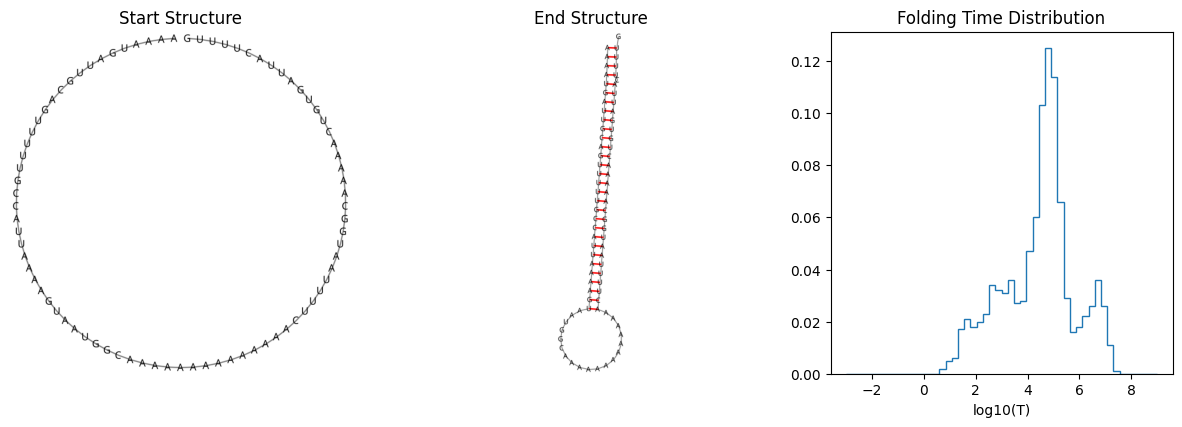

In [98]:
index = 10000

seq = df.loc[index, 'sequence']
struct = df.loc[index, 'mfe_structure']

fig, axs = plt.subplots(1, 3, figsize=(15,15))

axs[0].set_title('Start Structure')
axs[0].set_axis_off()
axs[0].imshow(plt.imread(str(index)+'_structure_unfolded.png'))

axs[1].set_title('End Structure')
axs[1].set_axis_off()
axs[1].imshow(plt.imread(str(index)+'_structure.png'))

axs[2].set_title('Folding Time Distribution')
axs[2].set_box_aspect(1.0)
axs[2].set_xlabel('log10(T)')
axs[2].stairs(df.loc[index,'dist'], np.load(BIN_EDGES_PATH)/np.log(10))

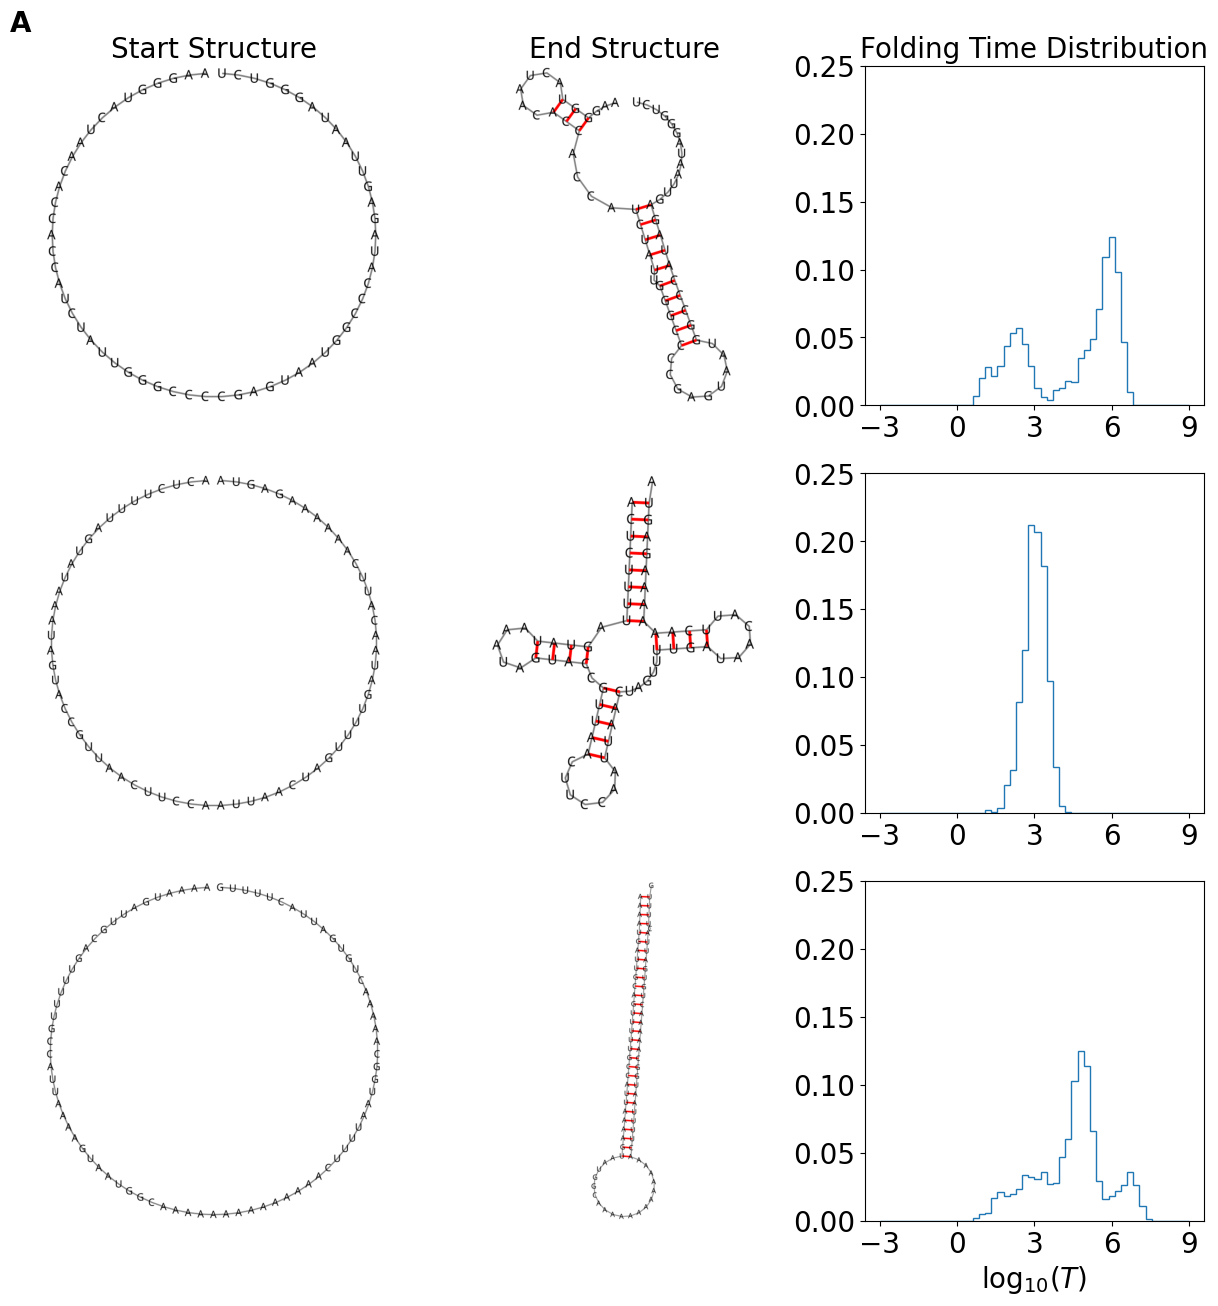

In [155]:
indices = [60, 8000, 10000]

fig, axs = plt.subplots(len(indices), 3, figsize=(15,len(indices)*5))

for i in range(len(indices)):
    index = indices[i]
    seq = df.loc[index, 'sequence']
    struct = df.loc[index, 'mfe_structure']

    if i == 0:
        axs[i][0].set_title('Start Structure', size=20)
        axs[i][1].set_title('End Structure', size=20)
        axs[i][2].set_title('Folding Time Distribution', size=20)

    axs[i][0].set_axis_off()
    axs[i][0].imshow(plt.imread(str(index)+'_structure_unfolded.png'))
    
    axs[i][1].set_axis_off()
    axs[i][1].imshow(plt.imread(str(index)+'_structure.png'))

    axs[i][2].set_box_aspect(1.0)
    if i == len(indices)-1:
        axs[i][2].set_xlabel(r'$\text{log}_{10}(T)$', size=20)
    axs[i][2].set_xticks([-3,0,3,6,9])
    axs[i][2].set_ylim(0, 0.25)
    axs[i][2].tick_params(axis='x', labelsize=20)
    axs[i][2].tick_params(axis='y', labelsize=20)
    axs[i][2].stairs(df.loc[index,'dist'], np.load(BIN_EDGES_PATH)/np.log(10))


axs[0][0].text(-0.1, 1.1, string.ascii_uppercase[0], transform=axs[0][0].transAxes,
               size=20, weight='bold')

plt.savefig('dataset_examples.png', bbox_inches='tight')
plt.savefig('dataset_examples.pdf', bbox_inches='tight')

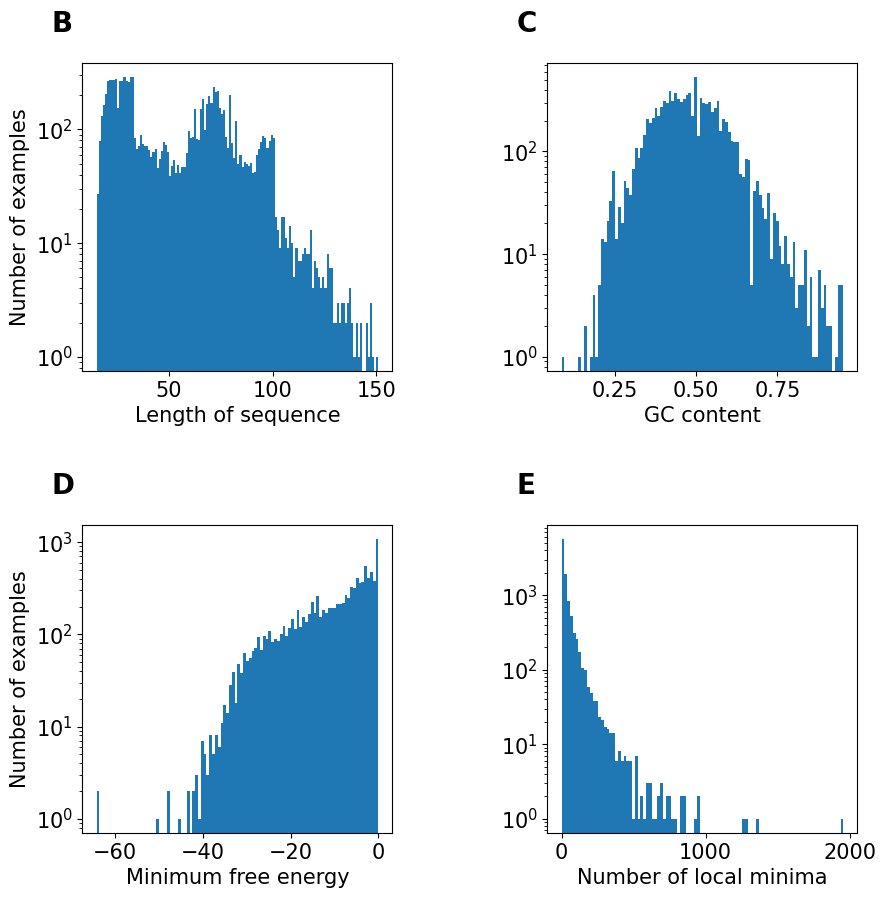

In [154]:
fig, axs = plt.subplots(2, 2, figsize=(10,10))
plt.subplots_adjust(wspace=0.5, hspace=0.5)

for i in range(2):
    for j in range(2):
        axs[i][j].tick_params(axis='x', labelsize=15)
        axs[i][j].tick_params(axis='y', labelsize=15)
        axs[i][j].set_yscale('log')
        if j==0:
            axs[i][j].set_ylabel('Number of examples', size=15)
        axs[i][j].text(-0.1, 1.1, string.ascii_uppercase[2*i+j+1], transform=axs[i][j].transAxes, 
               size=20, weight='bold')

axs[0][0].set_xlabel('Length of sequence', size=15)
axs[0][0].hist(df['length'], bins=np.arange(min(df['length']), max(df['length'])+1))

axs[1][0].set_xlabel('Minimum free energy', size=15)
axs[1][0].hist(df['mfe'], bins=100)

axs[0][1].set_xlabel('GC content', size=15)
axs[0][1].hist(df['gc_content'], bins=100)

axs[1][1].set_xlabel('Number of local minima', size=15)
axs[1][1].hist(df['n_local_minima'], bins=100)

plt.savefig('dataset_properties.png', bbox_inches='tight')
plt.savefig('dataset_properties.pdf', bbox_inches='tight')

In [158]:
np.load(BIN_EDGES_PATH)/np.log(10)

array([-3.        , -2.76010949, -2.52021898, -2.28032848, -2.04043797,
       -1.80054746, -1.56065695, -1.32076644, -1.08087594, -0.84098543,
       -0.60109492, -0.36120441, -0.1213139 ,  0.11857661,  0.35846711,
        0.59835762,  0.83824813,  1.07813864,  1.31802915,  1.55791965,
        1.79781016,  2.03770067,  2.27759118,  2.51748169,  2.75737219,
        2.9972627 ,  3.23715321,  3.47704372,  3.71693423,  3.95682474,
        4.19671524,  4.43660575,  4.67649626,  4.91638677,  5.15627728,
        5.39616778,  5.63605829,  5.8759488 ,  6.11583931,  6.35572982,
        6.59562032,  6.83551083,  7.07540134,  7.31529185,  7.55518236,
        7.79507287,  8.03496337,  8.27485388,  8.51474439,  8.7546349 ,
        8.99452541])

In [10]:
min_medianlog10fpt = 0
max_medianlog10fpt = 0

for row in df.itertuples():
    data = row.fpts
    where_data_zero = np.where(data == 0)[0]
    if len(where_data_zero) != 0:
        print(row.Index, len(where_data_zero))
        
    where_data_nonzero = np.where(data != 0)[0]
    log_data = np.log10(data[where_data_nonzero])
    
    min_medianlog10fpt = min(np.median(log_data), min_medianlog10fpt)
    max_medianlog10fpt = max(np.median(log_data), max_medianlog10fpt)

print(f'min_medianlog10fpt: {min_medianlog10fpt}, max_medianlog10fpt: {max_medianlog10fpt}')

251 1
258 1
274 7
333 1
349 2
453 1
459 1
464 1
465 4
478 1
480 2
482 1
484 4
491 4
527 1
1373 1
1441 1
1490 3
1497 1
1510 3
1514 2
1531 1
1897 1
2157 1
2167 2
2179 1
2183 1
2201 1
2220 1
2235 1
2245 1
2248 1
2253 2
2255 1
2256 2
2257 1
2267 1
2282 3
2295 1
2296 2
2298 2
2316 2
2322 1
2328 3
2355 2
2361 3
2381 2
2390 1
2446 1
2655 1
2660 1
2663 1
2670 1
2672 1
2677 3
2678 1
2686 2
2688 1
2702 1
2703 1
2705 1
2707 1
2713 1
2714 1
2719 2
2720 1
2724 1
2734 2
2736 2
2749 1
2750 2
2754 1
2768 2
2772 1
2773 1
2780 1
2782 1
2786 2
2792 1
2798 1
2806 1
2807 2
2813 1
2816 1
2823 1
2824 1
2825 1
2832 1
2837 1
2854 1
2869 1
2873 3
2877 1
2893 3
2898 1
2899 1
2903 4
2905 1
2913 2
2923 1
2928 2
2936 1
2938 1
2944 1
2946 1
2954 1
2957 1
2958 1
2963 3
2975 1
2980 1
2985 1
2991 3
2996 1
3006 1
3012 1
3016 2
3017 1
3021 1
3023 1
3027 1
3037 1
3047 2
3050 1
3064 1
3076 2
3084 1
3087 1
3098 1
3109 1
3113 1
3132 1
3134 2
3154 2
3181 1
3190 3
3191 1
3193 1
3211 1
3217 1
3227 1
3231 2
3235 1
3238 2
3239 1


In [11]:
len(df['sequence'])

10325

In [13]:
len(df['rnacentral_id'])

10325

In [30]:
mask = df['rnacentral_id'].apply(lambda id: id == None)

In [31]:
np.sum(mask)

np.int64(2654)

In [32]:
10325 - 2654

7671